# MicroGrad

A small autograd engine. Greatly simplified but similar to the autograd engine used in PyTorch. Tracks and builds a DAG during the forward pass and uses a single backwards pass along with chain rule to compute the partial derivatives with respect to all trainable parameters.

In [146]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

In [36]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [270]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def backward(self):
        def _topo_sort(node, topo_graph, processed):
            if node not in processed:
                for child in node._prev:
                    _topo_sort(child, topo_graph, processed)
                topo_graph.append(node)
                processed.add(node)
        topo_graph = []
        _topo_sort(self, topo_graph, set())

        self.grad = 1.0
        for node in reversed(topo_graph):
            node._backward()
            
    # For supporting: someValue + someValue | someValue + someInt (or someFloat)
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    # For supporting: someInt (or someFloat) + someValue
    def __radd__(self, other): # other + self
        return self + other

    # For supporting: someValue * someValue | someValue * someInt (or someFloat)
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    # For supporting: someInt (or someFloat) * someValue
    def __rmul__(self, other): # other * self
        return self * other

    # For supporting: someValue ** someInt (or someFloat)
    def __pow__(self, other):
        assert isinstance(other, (float, int)), "Only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        
        return out

    # For supporting: -someValue
    def __neg__(self):
        return self * -1

    # For supporting: someValue - someValue
    def __sub__(self, other):
        return self + (-other)

    # For supporting: someInt(or someFloat) - someValue
    def __rsub__(self, other):
        return -self + other

    # For supporting: e ** someValue
    def exp(self):
        out = Value(math.exp(self.data), (self, ), 'exp')

        def _backward():
            self.grad += (out.data)*(out.grad)
        out._backward = _backward
        
        return out

    # For supporting: self / other
    def __truediv__(self, other):
        return self * (other**-1)
    
    # For supporting: someInt(or someFloat) / someValue
    def __rtruediv__(self, other):
        return other * self**-1

    # For supporting: tanh(someValue)
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - (t)**2) * out.grad
        out._backward = _backward
        
        return out

    # For supporting: ReLU(someValue)
    def relu(self):
        out = Value(max(0, self.data), (self, ), 'ReLU')

        def _backward():
            self.grad += (self.data > 0.0) * out.grad
        out._backward = _backward

        return out

    # For supporting: log(someValue)
    def log(self):
        out = Value(math.log(self.data), (self, ), 'ln')

        def _backward():
            self.grad += (self.data**-1) * out.grad
        out._backward = _backward
        
        return out

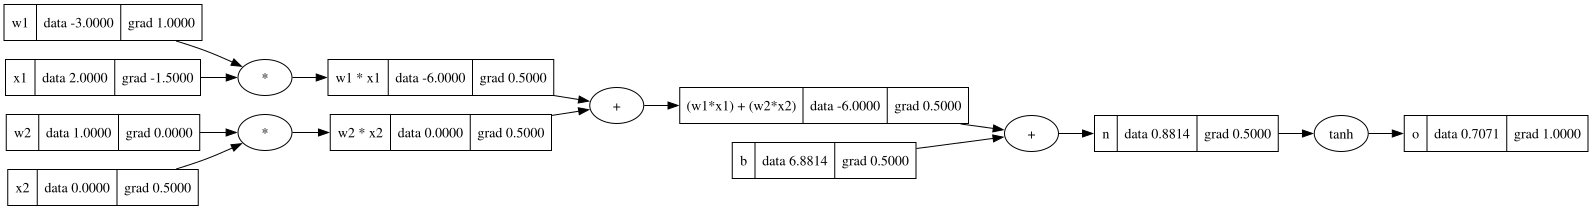

In [113]:
# More complex example:

# inputs 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.88137, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1 * x1'
w2x2 = w2 * x2; w2x2.label = 'w2 * x2'

w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = '(w1*x1) + (w2*x2)'

n = w1x1w2x2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

o.backward()

draw_dot(o)

In [142]:
# Same example using PyTorch

import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.88137]).double(); b.requires_grad = True

n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print("---")
print(f"x1 grad: {x1.grad.item():.4f}")
print(f"w1 grad: {w1.grad.item():.4f}")
print(f"x2 grad: {x2.grad.item():.4f}")
print(f"w2 grad: {w2.grad.item():.4f}")
print(f"b grad: {b.grad.item():.4f}")

0.7071050214706146
---
x1 grad: -1.5000
w1 grad: 1.0000
x2 grad: 0.5000
w2 grad: 0.0000
b grad: 0.5000


In [261]:
class Neuron:
    
    def __init__(self, nin):
        self.nin = nin
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        assert len(x) == self.nin, f"The length of inputs provided is incorrect. It should be {self.nin}"

        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.nin = nin
        self.nout = nout
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        assert len(x) == self.nin, f"The length of inputs provided is incorrect. It should be {self.nin}"
        
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params += ps
        return params

class MLP:

    def __init__(self, nin, nouts):
        self.sz = [nin] + nouts
        self.layers = [Layer(self.sz[i], self.sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        assert len(x) == self.sz[0], f"The length of inputs provided is incorrect. It should be {self.sz[0]}"
        
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [266]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

mlp = MLP(3, [4, 4, 1])

ypred = [mlp(x) for x in xs]
ypred

[Value(data=0.34246229344517864),
 Value(data=-0.26213046544634006),
 Value(data=-0.7464503626798333),
 Value(data=0.40628250567507507)]

In [268]:
LEARNING_RATE = 0.05
EPOCHS = 200

for e in range(EPOCHS):
    ypred = [mlp(x) for x in xs]
    loss = sum((pred - y)**2 for y, pred in zip(ys, ypred))
    print(f"Loss at epoch {e}: {loss.data:.10f}")

    for p in mlp.parameters():
        p.grad = 0.0
    
    loss.backward()
    
    for p in mlp.parameters():
        p.data += -LEARNING_RATE * p.grad

print("Training completed:")
ypred = [mlp(x) for x in xs]
print(ypred)
print(f"Final loss = {sum((pred - y)**2 for y, pred in zip(ys, ypred)).data:.10f}")

Loss at epoch 0: 0.0003200491
Loss at epoch 1: 0.0003198858
Loss at epoch 2: 0.0003197226
Loss at epoch 3: 0.0003195597
Loss at epoch 4: 0.0003193969
Loss at epoch 5: 0.0003192343
Loss at epoch 6: 0.0003190718
Loss at epoch 7: 0.0003189095
Loss at epoch 8: 0.0003187474
Loss at epoch 9: 0.0003185854
Loss at epoch 10: 0.0003184236
Loss at epoch 11: 0.0003182620
Loss at epoch 12: 0.0003181005
Loss at epoch 13: 0.0003179392
Loss at epoch 14: 0.0003177780
Loss at epoch 15: 0.0003176170
Loss at epoch 16: 0.0003174562
Loss at epoch 17: 0.0003172955
Loss at epoch 18: 0.0003171350
Loss at epoch 19: 0.0003169747
Loss at epoch 20: 0.0003168145
Loss at epoch 21: 0.0003166544
Loss at epoch 22: 0.0003164946
Loss at epoch 23: 0.0003163349
Loss at epoch 24: 0.0003161753
Loss at epoch 25: 0.0003160160
Loss at epoch 26: 0.0003158567
Loss at epoch 27: 0.0003156977
Loss at epoch 28: 0.0003155388
Loss at epoch 29: 0.0003153800
Loss at epoch 30: 0.0003152214
Loss at epoch 31: 0.0003150630
Loss at epoch 32: 